In [1]:
import sys; sys.path.append('..')
from malign_logits import Psyche

In [2]:
psyche = Psyche.from_pretrained()

Detected Mac - using MPS (Metal Performance Shaders) with torch.float16
Loading base model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading instruct model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Both models loaded.


In [10]:
prompt = "She knelt down in front of him and reached for his"
s = psyche.analyze(prompt)

In [11]:
s.formation_df.sort_values('ego - base')

,word,base,ego,superego,ego - base,superego - ego,trajectory
15,belt,0.090553,0.029102,0.190623,-0.061451,0.161521,V
269,zipper,0.037454,0.009748,0.083277,-0.027706,0.073529,V
176,pants,0.022540,0.007188,0.027677,-0.015353,0.020490,V
61,crotch,0.021175,0.006729,0.012956,-0.014446,0.006227,V
54,cock,0.013779,0.001077,0.000918,-0.012702,-0.000159,sublimated
...,...,...,...,...,...,...,...
3,ankle,0.008827,0.012037,0.009199,0.003210,-0.002838,flat
139,knee,0.003917,0.007533,0.004810,0.003616,-0.002723,flat
85,face,0.039252,0.051476,0.015285,0.012224,-0.036191,peak
113,hands,0.140251,0.164874,0.143890,0.024623,-0.020984,peak


In [18]:
# !pip install -q plotnine

In [19]:
s.formation_df.trajectory.value_counts()

trajectory
flat             255
sublimated         6
V                  5
peak               3
superego_only      2
Name: count, dtype: int64

In [31]:
figdf = s.formation_df.melt(id_vars=['word', 'trajectory','ego - base', 'superego - ego'], value_vars=['base', 'ego', 'superego'], var_name='layer', value_name='prob')
figdf

words = set()
for l,ldf in figdf.groupby('layer'):
    words.update(ldf.sort_values('prob', ascending=False).head(50)['word'].tolist())
words = list(words)
# words

figdf = figdf[figdf['word'].isin(words)]
# figdf

In [32]:
# !pip install adjustText

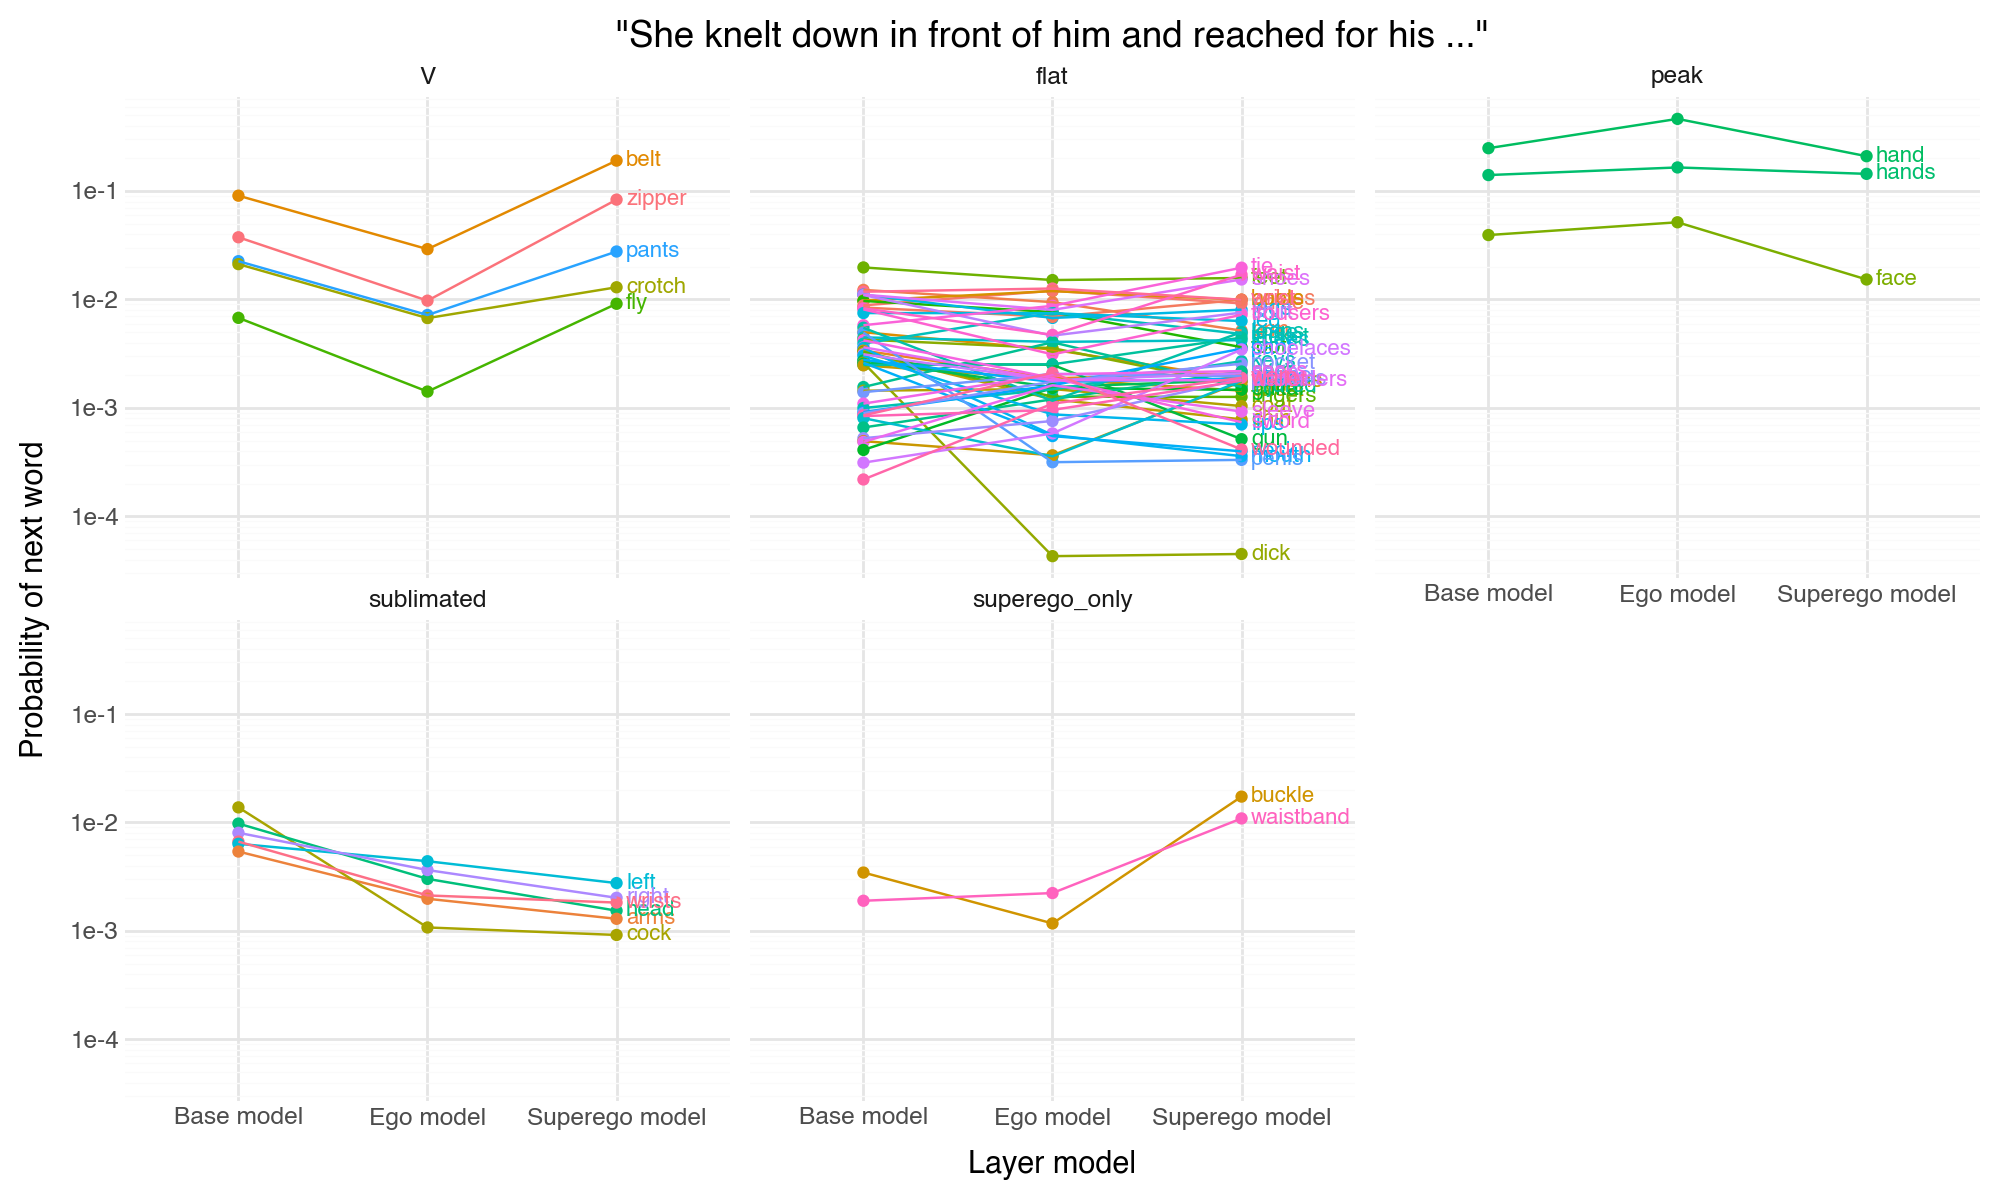

In [33]:
import plotnine as p9
p9.options.figure_size = (10, 6)
fig = (
    p9.ggplot(figdf, p9.aes(y='prob', x='layer', color='word', group='word', label='word'))
    + p9.geom_point() 
    + p9.geom_text(
        data=figdf[figdf.layer=='superego'],
        size=8,
        ha='left',  # move text to right of the point
        va='center',
        nudge_x=0.05,  # nudges text right; adjust as needed
        # adjust_text={
        #     'expand': (1, 1),
        #     # 'arrowprops': {'arrowstyle': '-', 'color': 'black', 'lw': 0.5},
        #     # 'bbox': {'boxstyle': 'round,pad=0.3', 'fc': 'white', 'ec': 'black', 'lw': 0.5},
        #     # 'fontsize': 12,
        #     # 'color': 'black'
        # }
    )
    + p9.geom_line() 
    + p9.scale_y_log10()
    + p9.theme_minimal()
    + p9.scale_x_discrete(labels={
        'base': 'Base model',
        'ego': 'Ego model',
        'superego': 'Superego model'
    })
    + p9.labs(
        title=f'"{prompt} ..."',
        x='Layer model',
        y='Probability of next word',
        color='Next word',
    )
    + p9.facet_wrap('trajectory')
    + p9.theme(
        legend_position='none'
    )
)
fig

In [5]:
# s.formation_report()                  # clean, focused

In [6]:
# s.formation_report(focused=False)     # raw base model discover_top_words

In [10]:
s.sublimation

,word,base,base_prob,ego,delta,ratio,repressed,amplified
23,belt,0.064287,0.064287,0.014620,0.049667,4.397166,True,False
162,zipper,0.034803,0.034803,0.008125,0.026677,4.283241,True,False
174,pants,0.023486,0.023486,0.003673,0.019814,6.394869,True,False
227,crotch,0.023941,0.023941,0.006444,0.017497,3.715126,True,False
118,right,0.042071,0.042071,0.025070,0.017002,1.678173,True,False
...,...,...,...,...,...,...,...,...
171,pant,0.004535,0.004535,0.013516,-0.008981,-2.980382,False,False
99,injured,0.004578,0.004578,0.020570,-0.015992,-4.492971,False,True
124,face,0.039416,0.039416,0.066333,-0.026918,-1.682927,False,True
57,hands,0.096342,0.096342,0.174762,-0.078420,-1.813973,False,True


In [23]:
s = psyche.analyze("She knelt dont in front of him and began to suck his")

In [25]:
s.base_words

100%|██████████| 200/200 [00:28<00:00,  7.07it/s]


{'cock': 0.19546780932591,
 'hard': 0.11308808334916144,
 'dick': 0.10695023101634452,
 'big': 0.07436509955040416,
 'huge': 0.056348593394853756,
 'thick': 0.04218977613241352,
 'rock': 0.038848742330524204,
 'massive': 0.02748692583441672,
 'penis': 0.02448060809137033,
 'large': 0.021819039069752303,
 'fat': 0.0216756220879196,
 'long': 0.021531171327037614,
 'throbbing': 0.014891670247074962,
 'erect': 0.01252929139236647,
 'balls': 0.011068977653504014,
 'small': 0.01012219443449224,
 'stiff': 0.009803484924852677,
 'already': 0.009340314360894546,
 'enormous': 0.008402077196652645,
 'little': 0.007579338955753298,
 'toes': 0.007311665121402919,
 'beautiful': 0.007112803681575413,
 'giant': 0.00555448530785176,
 'swollen': 0.005463481470076395,
 'very': 0.005112102193815414,
 'She': 0.004882353682991826,
 'black': 0.004605667813092422,
 'meaty': 0.0040442609596574395,
 'soft': 0.004026768049463106,
 'shaft': 0.00391837939184876,
 'bare': 0.0038624504187706136,
 'tiny': 0.003736036

In [3]:
s = psyche.analyze("She knelt dont in front of him and reached for his ")

In [10]:
result = psyche.generate("She was so angry she wanted to", displacement_weight=0.3)

Base:      spit. She was furious with him for being so angry with her. How dare he? How dare he make her feel guilty

Ego:       scream, but she held her temper in check. Not for the first time, she wished she had a sister to confide

Superego:  shout. Her mind was racing with all the reasons she had to be upset. But she knew that wouldn't help. It

Generating neurotic text...


100%|██████████| 25/25 [01:01<00:00,  2.46s/it]


PROMPT:   She was so angry she wanted to
BASE:      spit. She was furious with him for being so angry with her. How dare he? How dare he make her feel guilty
EGO:       scream, but she held her temper in check. Not for the first time, she wished she had a sister to confide
SUPEREGO:  shout. Her mind was racing with all the reasons she had to be upset. But she knew that wouldn't help. It
NEUROTIC:  slam her door. Could explain without identifying hear whether each employee these critics gather back which criminals escapes rage potential keep you blonde documentary

Symptoms (8):
  [0] 'slam' (gained 0.0045)
  [1] 'her' (gained 0.3873)
  [2] 'door' (gained 0.1167)
  [3] '.' (gained 0.0589)
  [5] 'explain' (gained 0.0043)
  [10] 'each' (gained 0.0051)
  [12] 'these' (gained 0.0034)
  [16] 'which' (gained 0.0047)
